# **<span style="color:#66CCFF">Walkthrough Notebook:**</span> How to Use *Sympy.py* to Expand a Higher Order Harmonic Series to Model Harmonic Currents in Potentiostatic EIS/NLEIS Experiments
#### Author: Lauren Frank



In [36]:
import sympy as sp
import json
import copy

## <ins>1. Background</ins>

#### **<span style="color:tomato;">Electrochemical impedance spectroscopy (EIS)</span>** is a valuable tool for probing the kinetic, transport, and thermodynamic behaviors of an electrode interface; however, as the perturbation of voltage or current increases, higher order harmonic contributions can begin to corrupt a linear, measured signal. For these reasons, physics-based models must consider higher harmonic effects to accuractely describe nonlinear behavior. In a 2025 publication [––insert title––], Lauren Frank and Dan Schwartz propose a low-frequency, diffusion-limited model for a ferri-/ferrocyanide system to characterize redox diffusion asymetry. With the addition of higher-order correction terms, the model becomes overwhelmingly difficult to derive by hand due to the expansion and sorting of several thousand, and even millions, of terms. While leading 2nd-order models can be derived by hand, these models perform poorly for large modulations (∆E > 10 mV) due to higher-order harmonic growth (3rd, 4th, ...) impeding linear analysis [See Publication]. To address this challenge, the *SymPy* mathematics package was employed, as demonstrated in this Notebook, to construct a transferrable framework for computing and filtering fourth- and sixth-order harmonic expansions. This technique enables the estimation of individual molecular diffusivities for redox species, such as ferri- and ferrocyanide, from potentiostatic EIS and second-harmonic nonlinear EIS (NLEIS) measurements. See paper for more detailed description of system specifications and assumptions.

## <ins>2. Theory</ins>

## a. Nernst Expansion

#### Ferri- and Ferrocyanide reversibly react in the following reaction:
$$
{Fe(CN)_6}^{3-} [ferricyanide] + e^- \rightleftharpoons {Fe(CN)_6}^{4-} [ferrocyanide] \tag{1}
$$

#### where ferricyanide [Fe(III) species] forms ferrocyanide [Fe(II) species] in the forward reaction. At the platinum electrode's surface, the **<span style="color:darkgoldenrod;">surface concentration ratio</span>** between species Fe(II) and Fe(III) can be represented using the Nernst Equation:
$$
\frac{c^{s,III}}{c^{s,II}} = e^{f(E_n-E_0)} \tag{2}
$$
#### where $c^{s,i}$ is the total surface concentration of Fe-species $i$ (mol/L), $E_n - E_0$ is the voltage difference between the Nernst and reference potential (V), and $ƒ = \frac{F}{RT}$, such that $R$ is the gas constant $(J•mol^{-1}•K^{-1})$, $F$ is the Faraday’s Constant, and $T$ is the temperature ($K$). Assuming a purely real cosine input modulation, $E_n - E_0 = \Delta E \cdot \cos(\omega t) = \frac{\Delta E}{2} (e^{i\omega t} + e^{-i\omega t})$ and weakly nonlinear response $(f \cdot \Delta E \ll 1)$, Equation 2 can be expanded using a Maclaurin series for an exponential:
$$
\frac{c^{s,III}}{c^{s,II}} =
\underbrace{\left[1 + \frac{f^2 \Delta E^2}{4} + \ldots \right]}_{\text{Constant Term}} +
\underbrace{\left[ \frac{1}{2} f \Delta E + \ldots \right]}_{\text{1st Harmonic Term}} (e^{i\omega t} + e^{-i\omega t}) +
\underbrace{\left[ \frac{1}{8} f^2 \Delta E^2 + \ldots \right]}_{\text{2nd Harmonic Term}} (e^{i2\omega t} + e^{-i2\omega t}) + \ldots \tag{3}
$$

#### where ∆E real potential modulation (V). Equation 3 presents the leading 2nd-order substitution of the Maclaurin series of order $\mathcal{O}(∆E^2)$; however, each bracketed term can be extended to any $N-th$ order, $\mathcal{O}(∆E^N)$, as denoted by the $\ldots$ symbol. In doing so, an interesting pattern emerges relating to the parity of each harmonic and its inner terms:






<center>

| **Harmonic Order $j$** | **Fourier Component**                          | **$\Delta E$ Order of Inner Terms**                                 | **Parity of Inner Terms** |
|:------------------------:|:---------------------------------------------:|:------------------------------------------------------------------:|:---------------------:|
| 0 (Constant Coefficients)                 | 1                                     | $ 1, \ \mathcal{O}(\Delta E^2),\ \mathcal{O}(\Delta E^4),\ \dots $   | Even                |
| 1                      | $ (e^{i\omega t} + e^{-i\omega t}) $          | $ \mathcal{O}(\Delta E),\ \mathcal{O}(\Delta E^3),\ \dots $     | Odd                 |
| 2                      | $ (e^{i2\omega t} + e^{-i2\omega t}) $        | $ \mathcal{O}(\Delta E^2),\ \mathcal{O}(\Delta E^4),\ \dots $   | Even                |
| 3                      | $ (e^{i3\omega t} + e^{-i3\omega t}) $        | $ \mathcal{O}(\Delta E^3),\ \mathcal{O}(\Delta E^5),\ \dots $   | Odd                 |
| 4                      | $ (e^{i4\omega t} + e^{-i4\omega t}) $        | $ \mathcal{O}(\Delta E^4),\ \mathcal{O}(\Delta E^6),\ \dots $   | Even                |
| 5                      | $ (e^{i5\omega t} + e^{-i5\omega t}) $        | $ \mathcal{O}(\Delta E^5),\ \mathcal{O}(\Delta E^7),\ \dots $   | Odd                 |
| $\vdots$               | $\vdots$                                    | $\vdots$                                                        | $\vdots$            |
| $j$ (general)          | $ (e^{i j \omega t} + e^{-i j \omega t}) $    | $ \mathcal{O}(\Delta E^{j}),\ \mathcal{O}(\Delta E^{j+2}),\ \dots $ | Even if $j$ even, Odd if $j$ odd |

</center>

#### In summary, coefficients which appear in each harmonic contribution term must match the parity (even or odd) of that harmonic and have an order $\mathcal{O}(coefficient)$ ≥ the harmonic integer $j$. This pattern will become important later.

## b. Oscillating Electrode Surface Concentration

#### From the publication, it was assumed that the applied sinusoidal potential drives surface concentration oscillations near the electrode's surface within the electrolyte, such that both Fe-species concentration profiles resemble that of Stoke’s Second Problem. Further, this oscillatory form is:
$$
c^{s,III} = c^{b,III}+\frac{C_1^{s,III}}{2}*(e^{iωt}+e^{-iωt})+\frac{C_2^{s,III}}{2}*(e^{i2ωt}+e^{-i2ωt} )+ \ldots \tag{4}
$$
$$
c^{s,II} = c^{b,II}+\frac{C_1^{s,II}}{2}*(e^{iωt}+e^{-iωt})+\frac{C_2^{s,II}}{2}*(e^{i2ωt}+e^{-i2ωt} )+ \ldots \tag{5}
$$
#### where $c^{s,i}$ is the total surface concentration of Fe-species $i$ (mol/L) as defined in Equation 2 and $C^{s,i}_{j}$ is the real Fourier concentration coefficient (presumed by the purely real applied potential) for Fe-species $i$ oscillating at integer harmonic frequency $ω_j=j*ω$. Moreover, Equation 4 and 5 assume a stationary mean surface concentration equal to the bulk. From Equation 8 in Frank et. al, it was found that by setting the complex, steady periodic models of current for oxidation and reduction equal, that:
$$
{C_j^{s,II}=-C_j^{s,III}*\sqrt{\frac{D^{III}}{D^{II}}}} \tag{6}
$$

#### By substitution of Equation 6, and noting that $c^{b,II} = c^{b,III}=c^b$ for the prepared equimolar Fe-species electrolyte, Equation 5 can be rewritten in terms of the ferricyanide surface oscillations:
$$
c^{s,II} = c^{b}-\frac{C_1^{s,III}}{2}*\sqrt{\frac{D^{III}}{D^{II}}}*(e^{iωt}+e^{-iωt})-\frac{C_2^{s,III}}{2}*\sqrt{\frac{D^{III}}{D^{II}}}*(e^{i2ωt}+e^{-i2ωt} )+ \ldots \tag{7}
$$
#### A **<span style="color:darkgoldenrod;">new surface concentration ratio</span>**, analogous to Equation 3, can then be written using the oscillating surface concentration profiles from Equations 4 and 7 and division by $c^b$:
$$
\frac{c^{s,III}}{c^{s,II}} = \frac{1+\frac{C_1^{s,III}}{2c^b}*(e^{iωt}+e^{-iωt})+\frac{C_2^{s,III}}{2c^b}*(e^{i2ωt}+e^{-i2ωt} )+ \ldots}{1-\frac{C_1^{s,III}}{2c^b}*\sqrt{\frac{D^{III}}{D^{II}}}*(e^{iωt}+e^{-iωt})-\frac{C_2^{s,III}}{2c^b}*\sqrt{\frac{D^{III}}{D^{II}}}*(e^{i2ωt}+e^{-i2ωt} )+ \ldots} \tag{8}
$$


#### Assuming $\frac{C_1^{s,III}}{c^b} << 1$ and $\frac{C_2^{s,III}}{c^b} << 1$ for small potential modulations, the denominator can be expanded using a Maclaurin series of $\frac{1}{1-x}$:
$$
Σ = \frac{C_1^{s,III}}{2c^b}*(e^{iωt}+e^{-iωt})+\frac{C_2^{s,III}}{2c^b}*(e^{i2ωt}+e^{-i2ωt} )+ \ldots + \frac{C_N^{s,III}}{2c^b}*(e^{iNωt}+e^{-iNωt} ) \tag{9}
$$
$$
\frac{c_s^{III}}{c_s^{II}}= \frac{1+Σ}{1-aΣ} = [1+Σ][1+aΣ+(aΣ)^2+ \ldots + (aΣ)^N] \tag{10}
$$
#### where $a = \sqrt{\frac{D^{III}}{D^{II}}}$ and $\mathcal{O}(a) = 1$ for the molecularly similar ferri- and ferrocyanide species, for a given $N$-th order expansion. Moreover, depending on the chosen expansion order $N$ (i.e., the maximum power of $\Delta E$ retained), each concentration coefficient $C_j^{s,III}$ can be further **<span style="color:darkcyan;">separated into its individual modulation contributions</span>** $C_{j,k}^{s,III}$, such that:

$$
C_{j}^{s,III} = C_{j,j}^{s,III} + C_{j,j+2}^{s,III} + \ldots + C_{j,N}^{s,III} \tag{11}
$$

#### Here, $C_{j,k}^{s,III}$ is the real Fourier concentration coefficient for the Fe-species $i$, oscillating at the $j$-th harmonic frequency $\omega_j = j*\omega$ and $k$-th order modulation, where $\mathcal{O}(C_{j,k}^{s,III}) = \Delta E^k$. Importantly, the highest-order term included, $C_{j,N}^{s,III}$, must match the parity of the harmonic index $j$. For example, when $N = 4$, the first harmonic coefficient $C_{1}^{s,III}$ (corresponding to $j = 1$) includes terms up to $C_{1,3}^{s,III}$, not $C_{1,4}^{s,III}$.




#### Substituting Equation 11 into Equation 10 and expanding the multiplication, the resulting series can be re-arranged into the following **<span style="color:darkgoldenrod;">general form</span>**:
<!-- $$
\frac{c_s^{III}}{c_s^{II}}=
\underbrace{
\left[\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,2} + \left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,4}+  \ldots +\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,N}\right]
}_{\text{Constant Coefficients}}
+ 
\underbrace{
\sum\limits_{j=1}^N \left[\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,j} + \left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,j+2}+  \ldots +\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,N}\right] * (e^{ji\omega t} + e^{-ji\omega t})
}_{\text{Harmonic Coefficients}}
\tag{12}
$$ -->
$$
\frac{c_s^{III}}{c_s^{II}}=
\underbrace{
\left[\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,2} + \left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,4}+  \ldots +\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,N}\right]
}_{\text{Constant Term}}
+ 
\sum\limits_{j=1}^N \underbrace{\left[\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,j} + \left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,j+2}+  \ldots +\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,N}\right]}_{\text{Harmonic Terms}} * (e^{ji\omega t} + e^{-ji\omega t})
\tag{12}
$$

#### where $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}$ denotes the grouped oscillating coefficient terms, each functions of the underlying concentration coefficients $C_{j,k}^{s,III}$. Because Equation 10 distributes the product of two power series, terms within each group can contain various combinations of multiplied coefficients, like {$C_{j_1,k_1}^{s,III} * C_{j_2,k_2}^{s,III} * \ldots$}, where the harmonic indices {$j_1$,$j_2$, $\ldots$} and modulation indices {$k_1, k_2, \ldots$} may vary — provided the total order of each term still satisfies:
$$
\mathcal{O}\left(\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}\right) = \Delta E^k \tag{13}
$$
#### This is because the multiplying of powered terms involves the adding of exponents (e.g., $\Delta E^{k_1} \cdot \Delta E^{k_2} = \Delta E^{k_1 + k_2}$). For context, after filtering and sorting an $N=4$ expansion, $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{1,3}$ may look like: {$\frac{3{(C_{1,1}^{s,III})}^3a^3}{8(c^b)^3} + \frac{C_{1,1}^{s,III}C_{2,2}^{s,III}a^2}{2(c^b)^2} + \dots $} since these terms are both $\mathcal{O}(∆E^3)$. However, you would not find terms like: $\frac{3{(C_{1,3}^{s,III})}^3a^3}{27(c^b)^3}$, $\frac{C_{1,3}^{s,III}C_{2,2}^{s,III}}{2(c^b)^2}$ or $\frac{C_{1,1}^{s,III}}{2c^b}$, since these are of order $\mathcal{O}(∆E^9)$, $\mathcal{O}(∆E^5)$, and $\mathcal{O}(∆E^1)$, which all $\neq$ $\mathcal{O}(∆E^3)$ and violate Equation 13. Similarily, you would not find terms like: $\frac{3C_{5,1}^{s,III}a^3}{27c^b}$ or $\frac{3C_{1,5}^{s,III}a^3}{27c^b}$, since $j$ and $k$ are $> N=4$, violating Equation 12.


#### **<span style="color:tomato;">★ OBJECTIVE</span>**: Using the Nernst Expansion (Equation 3) and Oscillating Concentration Ratio (Equation 12), each $C_{j,k}^{s,III}$ coefficient can be analytically determined. This is done by mapping each $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}$ in Equation 12 to its corresponding coefficient in Equation 3 with the same $∆E$ order. This notebook will carefully walk-through this procedure, first expanding each series, filtering out terms of order > $\mathcal{O}(∆E^N)$ and $j > N$, and analytically solving the system of equations, to finally determine each harmonic current using the relationship in Frank et. al:
$$
\frac{\tilde{I}_j}{C_j^{s,III}} = FA \sqrt{\frac{j \omega D^{III}}{2}} (1 + i) \tag{14}
$$
#### This notebook will demonstrate how Equation 14 provides **<span style="color:gold;">new information</span>** about the <u>diffusion asymmetry</u> of ferri- and ferrocyanide through a complemtary analysis of the first and second harmonics.

## <ins>2. Series Expansion</ins>

#### The following example will be creating a <ins>4th-ordered current model</ins>; however, additional information will be provided for how to implement this workflow using a higher ordered series (i.e 6th-order), where a few minor modifications are needed in order to run the notebook due to timeout errors.

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Define System Variables

In [40]:
#Define System Variables
w, t, a, f, E, C_11, C_13, C_22, C_24, C_3, C_4, c_b = sp.symbols(r'\omega t a f E C_{11}^{S} C_{13}^{S} C_{22}^{S} C_{24}^{S} C_{3}^{S} C_{4}^{S} c^{b}',real=True)
sp.init_printing(use_unicode=True) #prints terms in series using a human-readable format

#Sympy Fraction
one_half = sp.Rational(1, 2) #needed to avoid solutions having decimal notation

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Define 4th-Ordered Series

In [49]:
# Summation Term (∑) - Equation 9
E_eq = (
    one_half * (C_11 + C_13) / c_b  * (sp.exp(sp.I*w*t) + sp.exp(-sp.I*w*t)) +
    one_half * (C_22 + C_24) / c_b * (sp.exp(2*sp.I*w*t) + sp.exp(-2*sp.I*w*t)) +
    one_half * C_3 / c_b * (sp.exp(3*sp.I*w*t) + sp.exp(-3*sp.I*w*t)) +
    one_half * C_4 / c_b * (sp.exp(4*sp.I*w*t) + sp.exp(-4*sp.I*w*t))
)
#Concentration Ratio - Equation 10
series = (1 + E_eq) * (1 + a*E_eq + (a*E_eq)**2 + (a*E_eq)**3 + (a*E_eq)**4)

### c. Sympy Expansion of Concentration Ratio

In [50]:
series_expanded = sp.expand(series) #Sympy expansion of multiplication
series_expanded_terms = series_expanded.as_ordered_terms() #puts the terms from the expanded series into a list

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<ins>For context</ins>, see the first 25 expanded terms in the series:

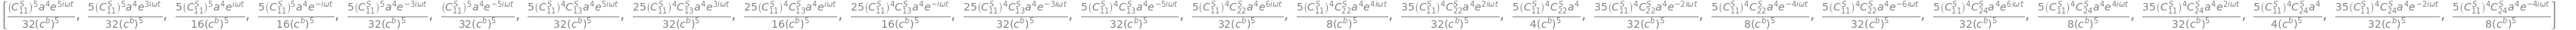

In [51]:
series_expanded_terms[0:25]

### d. Addtional Information: Sympy Expansion of Higher Order Series (6th order and higher)

#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Due to timeout issues when using a Jupyter notebook, it is recommended to conduct the expansion of higher order series in a separate python file and save the results to a json file to re-import into the notebook for the rest of the analysis. An example will be shown later in the next section to use in conjunction with the filtering/sorting functions.

## <ins>3. Surface Concentration Coefficient Filtering and Sorting</ins>

#### As explained before, each $C_{j,k}^{s,III}$ coefficient is of order $∆E^k$. For example, in the first harmonic $(e^{i\omega t} + e^{-i\omega t})$, $C_{1,1}^{s,III}$ is of the power $\Delta E^1$ where $C_{1,3}^{s,III}$ is of the power $\Delta E^3$. However, upon expansion of the series in Equation 10, these coefficients are mixed together when distributed amongst the parentheses through multiplication. In order to solve for these coefficients, the total $\Delta E^k$ power of each term in the expanded series needs to be evaluated. Moreover, the multiplication and raising of exponents for each of the individual coefficients needs to also be accounted for.

#### To do so, the terms corresponding to each harmonic were filtered into separate bins, where terms were removed if $k > N$ (i.e., 4th order, 6th order expansion terms), or if the multiplied harmonic $(e^{ij\omega t} + e^{-ij\omega t})$ had a number $j$ greater than this desired series order. See functions `filter_series` for how to remove h.o.t. terms and `sort_harmonics` for how to bin the filtered expansion terms based on their harmonic j:

In [ ]:
def filter_series(terms_list, N, wt_dict):
    
    '''
    Modifies an ordered set of terms by deleting h.o.t. (i.e O(term) > O(∆E^N) and j > N)
    
    Args:
        terms_list (list): ordered terms from expanded series
        N (int): highest ordered harmonic terms to keep (e.g. up to 4th order... N = 4)
        wt_dict (dict): dictionary where the keys are the sympy representations of each concentration coefficient
                        (e.g. C_11, C_3, etc.) and the values are the weights (∆E^k) of the different harmonics (e.g. C_11 = 1, C_3 = 3)
    
    Return:
        res (list): list of filtered terms
    '''
    
    res = []
    for term in terms_list:
        
        #Dictionary with base numbers as keys and exponents as values (e.g. C_11^2 * C_24^3 * a^2 ==> keys: C_11, C_24, a; values: 2, 3, 2)
        powers_dict = term.as_powers_dict()
        exp_key = sp.exp(1) #key --> sympy representation of exponential base e
        harmonic = -1
        
        if exp_key in powers_dict:

            #Harmonic Number of Exponential
            harmonic = int(abs(powers_dict[exp_key] / (sp.I * t * w))) #determines the harmonic number j of each term

            if harmonic > N:
                continue #removes terms with exponentials greater than n (j > n)
        
        #Calculates the Total ∆E^k of each Term
        pow = 0
        for key in powers_dict:
            temp_key = str(key) #converts Sympy representation of variable to explicit string
            if temp_key in wt_dict:
                wt = wt_dict[temp_key] #∆E^k weight (e.g C_24 ==> wt = 4)
                exp = powers_dict[key] #Raised Exponent of Term (e.g. C_24^3 ==> exp = 3)
                pow += wt * exp #∆E^(k_1*exp_1) * #∆E^(k_2*exp_2) * .... #∆E^(k_i*exp_i)  ==>  k power = (k_1*exp_1) + (k_2*exp_2) + ... (k_i*exp_i)              
        if pow <= N:
            res.append(term) #Adds terms only if the summed exponents (k) is less than / equal to 'N'  
    
    return res

In [ ]:
def sort_harmonics(filtered_terms):
        
    '''
    Sorts the different terms into respective harmonic bins via a dictionary [keys are const, 1, 2, 3, ...; values are series of terms]
    
    Args:
        filtered_terms (list): list containing the terms that have been filtered
    
    Return:
        res_dict (dict): dictionary containing the sorted terms with exponentials still attatched
    
    '''
    
    res_dict = {"const":[]}
    for term in filtered_terms:
        
        #Dictionary with base numbers as keys and exponents as values (e.g. C_11^2 * C_24^3 * a^2 ==> keys: C_11, C_24, a; values: 2, 3, 2)
        powers_dict = term.as_powers_dict()
        exp_key = sp.exp(1) #key --> sympy representation of exponential base e
        
        if exp_key in powers_dict:

            harmonic = int(abs(sp.simplify(powers_dict[exp_key] / (sp.I * t * w)))) #determines the harmonic number j of each term

            if harmonic in res_dict:
                val = res_dict[harmonic]
                res_dict[harmonic] = val + [term] #adds term to existing harmonic series
            else:
                res_dict[harmonic] = [term] #creates first term in new harmoinc series
        else:
            res_dict["const"] += [term] #adds to const bin if no harmonic contribution detected
                
    return res_dict
        

#### After sorting the terms into separate bins for each harmonic (i.e., constants, 1, 2, 3, ...) based on the multiplied exponential $e^{ij\omega t}$ or $e^{-ij\omega t}$, exponential pairs $(e^{ij\omega t} + e^{-ij\omega t})$ were reformed and used to extract the leading coefficients (the summed inner terms). See function `get_coeff` below for this process:

In [49]:
def get_coeff(terms,harm):
    
    '''
    Extracts the coefficients of each harmonic by combining (+) and (-) exponent pairs and factoring out the constants in front of each into a list
    
    Args:
        terms (list): specific list of harmonic terms from res_dict at a single harmonic
        harm (int): harmonic number that alligns with the provided terms
    
    Return:
        coeff_list (list): list of coefficients for the specified harmonic termed list
    
    '''
    
    coeff_list= []
    for term in terms:
        powers_dict = term.as_powers_dict()
        exp_key = sp.exp(1)
        exp = int((sp.simplify(powers_dict[exp_key] / (harm * sp.I * t * w))))
        coeff = term / sp.exp(harm * exp * sp.I * t * w)
        coeff_list.append(coeff)
    coeff_list = coeff_list[::2]
    
    return coeff_list## Expansion + Filtering

#### Within each set of inner terms for a specific harmonic $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_j$, each term can have a different $∆E^k$ power (e.g. first harmonic terms => $∆E^1$, $∆E^3$, $\ldots$). To further characterize these harmonics, the terms with different $∆E^k$ power are also separated in order to find the oscillating grouped terms $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}$ for each harmonic $j$ and modulation power $k$. See function `sep_coeff` for this process:

In [5]:
def sep_coeff(coeff_list, wt_dict):

    '''
    Creates a dictionary from a coeff_list, where the keys are the different total powers, k,
    of the terms and the values are lists containing the terms with those total powers. 
    This is used to extract/seperate the different contribution terms from a single harmonic 
    (e.g first harmonic - extract its first order (∆E^1) and third order (∆E^3) contributions separately).
    
    Args:
        coeff_list (list): list of coefficients for a single harmonic (output of get_coeff) (e.g )
        wt_dict (dict): dictionary where the keys are the differnt variables in the system 
        (e.g. C_3, C_3, etc.) and the values are the weights (∆E^w) of the different harmonics (e.g. C_3 = 3)
    
    Return:
        res_dict (dict): dictionary containing the terms of the coeff_list separated by keys 
        representing the harmonic totals
    
    '''
    
    res_dict = {}
    for coeff in coeff_list:
        
        powers_dict = coeff.as_powers_dict()
        pow = 0
        for key in powers_dict:
            temp_key = str(key)
            if temp_key in wt_dict:
                wt = wt_dict[temp_key]
                exp = powers_dict[key]
                pow += wt * exp
                
        if pow not in res_dict:
            res_dict[pow] = [coeff]
        else:
            val = res_dict[pow]
            res_dict[pow] = val + [coeff]    
            
    return res_dict
        

### <ins>★ To further understand how to use these functions, see the below example for the 4th-order series:</ins>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Extracted Grouped Oscillating Harmonic Terms $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_j$ (before filtering of $∆E^k$ within each Harmonic)

In [ ]:
#k value of ∆E^k for Single C_i
wt_dict = {
    'C_{11}^{S}':1,
    'C_{13}^{S}':3,
    'C_{22}^{S}':2,
    'C_{24}^{S}':4,
    'C_{3}^{S}':3,
    'C_{4}^{S}':4,
}

# Removes higher order terms (> N = 4)
filtered_terms = filter_series(series_expanded_terms,4,wt_dict)

#Sorts the Terms (Consts and Exponentials) into Different Harmonics (Exponentials still in terms)
harmonic_dict = sort_harmonics(filtered_terms)

#Extracts the Coefficients of Each Harmonic in front of the Exponential Pairs (e.g C_1*e^iwt + C_1*e^-iwt --> returns C_1 in first harmonic list)
term_1_series = get_coeff(harmonic_dict[1],1) #first harmonic
term_2_series = get_coeff(harmonic_dict[2],2) #second harmonic
term_3_series = get_coeff(harmonic_dict[3],3) #third harmonic
term_4_series = get_coeff(harmonic_dict[4],4) #fourth harmonic
const_series = harmonic_dict["const"] #constant

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_0$ =

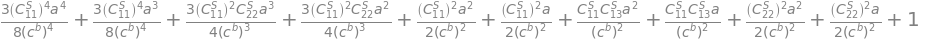

In [57]:
sum(const_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_1$ =

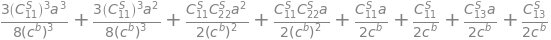

In [ ]:
sum(term_1_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_2$ =

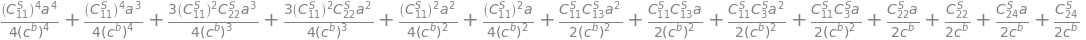

In [ ]:
sum(term_2_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_3$ =

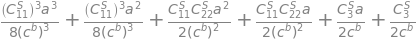

In [ ]:
sum(term_3_series)

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_4$ =

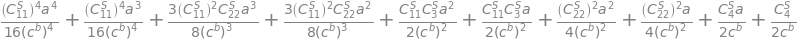

In [ ]:
sum(term_4_series)

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Separation of Extracted Harmonic Terms based on $∆E^k$ Powers $\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{j,k}$

In [ ]:
#Finds the unique k powers within a specific harmonic list and assigns each term accordingly (E.g. 1st harmonic --> ∆E^1 and ∆E^3 terms)
const_terms = sep_coeff(const_series, wt_dict)
const_2 = const_terms[2]
const_4 = const_terms[4]

term1_terms = sep_coeff(term_1_series,wt_dict)
term_1_1 = term1_terms[1]
term_1_3 = term1_terms[3]

term2_terms = sep_coeff(term_2_series,wt_dict)
term_2_2 = term2_terms[2]
term_2_4 = term2_terms[4]

#Re-stating Variable as series does not need to be separated
term_3 = term_3_series
term_4 = term_4_series

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0,2}$ =

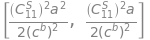

In [63]:
const_2

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{0.4}$ =

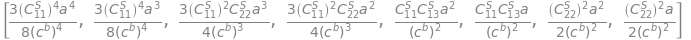

In [64]:
const_4

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{1,1}$ =

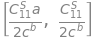

In [ ]:
term_1_1

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{1,3}$ =

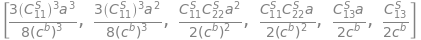

In [ ]:
term_1_3

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{2,2}$ =

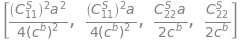

In [ ]:
term_2_2

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{2,4}$ =

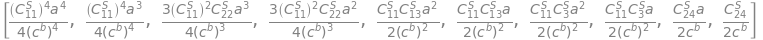

In [ ]:
term_2_4

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{3}$ =

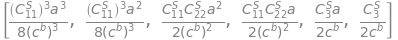

In [ ]:
term_3

$\left\langle \frac{C_s^{III}}{C_s^{II}} \right\rangle_{4}$ =

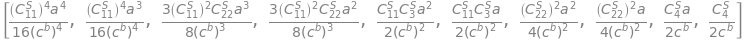

In [ ]:
term_4

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;c. Higher Order Series (6th Order or Higher)

<div class="alert alert-block alert-danger">
<b>Note:</b> Due to memory/timeout issues, higher-order expansions (≥6th-order) are recommended to be run outside the Jupyter notebook using <b>sixth_order_scipy.py</b> found in this directory. Harmonic terms can then be saved into a .json file and imported into this notebook, avoiding potential timeout errors. The results of the 6th-order model using this process can be found in <b>sixth_ordered_filtered_terms.json</b>. The same workflow can be modified to analyze any other higher-order models. See the implementation below.
</div>

In [ ]:
def get_dict(filepath,variables_dict):
    
    '''
    Creates a harmonic dictionary from a .json file and converts strings to correct sympy representation
    
    Args:
        filepath (str): filepath to .json file containing the higher-order term dictionary
        variables_dict (dict): dictionary where the keys are print representations for a set of Sympy variables
        (e.g. 'C_12', 'C_33', etc.) and the values are the associated Sympy variables (e.g. C_33 = sp.symbol(r'C_3',real=True))
    
    Return:
        loaded_data_sympy (dict): resulting harmonic dictionary
    '''
    
    with open(filepath, "r") as file:
        loaded_data = json.load(file)
        loaded_data_sympy = {key: sp.sympify(expr,locals=variables_dict) for key, expr in loaded_data.items()}
    return loaded_data_sympy

In [ ]:
def sub_repr(harmonic_dict,latex_map):
    '''
    Substitutes in new sympy variables with correct latex string representation.
    
    Args:
        harmonic_dict (dict): harmonic_dictionary returned by get_dict() containing incorrect Sympy variable represenations
        latex_map (dict): dictionary where the keys are Sympy variables used in the harmonic_dict input
        (e.g. C_12_t = sp.symbol(r'C_12',real=True)) and the values are the correctly latex-formatted Sympy variables (e.g. C_12 = sp.symbol(r'C_{12}^{S},real=True))
    
    Return:
        harmonic_dict_copy (dict): new harmonic dictionary containing the correctly formatted Sympy variables
    '''
    
    harmonic_dict_copy = copy.deepcopy(harmonic_dict)
    for key in harmonic_dict_copy:
        expressions = harmonic_dict_copy[key]
        new_expressions = []
        for expression in expressions:
            new_expressions.append(expression.subs(latex_map))
        harmonic_dict_copy[key] = new_expressions
    return harmonic_dict_copy

#### Latex variable representations (e.g. C_{15}^{S}) cannot be interpreted by the Sympy function, `Sympify`, when importing a .json file. Variables were instead renamed after importing the .json file with the corrected notation to match the rest of the notebook.

In [ ]:
filepath = "sixth_order_filtered_terms.json"

#Temporary Variables without correct latex representation that were used in .json (otherwise .json cannot be parsed)
C_11_t, C_13_t,C_15_t, C_22_t, C_24_t,C_26_t, C_33_t,C_35_t, C_44_t,C_46_t,C_5_t,C_6_t, c_b_t = sp.symbols(r'C_11 C_13 C_15 C_22 C_24 C_26 C_33 C_35 C_44 C_46 C_5 C_6 c_b',real=True)

#New Variables with Correct latex representation
C_15, C_26, C_33, C_35, C_44, C_46, C_5, C_6 = sp.symbols(r'C_{15}^{S} C_{26}^{S} C_{33}^{S} C_{35}^{S} C_{44}^{S} C_{46}^{S} C_{5}^{S} C_{6}^{S}',real=True)
latex_map = {
    C_11_t: C_11,
    C_13_t: C_13,
    C_15_t: C_15,
    C_22_t: C_22,
    C_24_t: C_24,
    C_26_t: C_26,
    C_33_t: C_33,
    C_35_t: C_35,
    C_44_t: C_44,
    C_46_t: C_46,
    C_5_t:  C_5,
    C_6_t:  C_6,
    c_b_t:  c_b
}
variables_dict = {'i':sp.I, 'w':w, 't':t, 'a':a, 'f':f, 'E':E, 'C_11':C_11_t, 'C_13':C_13_t,'C_15':C_15_t, 'C_22':C_22_t, 'C_24':C_24_t,'C_26_t':C_26_t, 'C_33':C_33_t,'C_35':C_35_t, 'C_44':C_44_t,'C_46':C_46_t,'C_5':C_5_t,'C_6':C_6_t}
harmonic_dict = get_dict(filepath,variables_dict)
new_harmonic_dict = sub_repr(harmonic_dict,latex_map) #corrected latex dictionary

#Extracts the Coefficients of Each Harmonic from Exponentials (e.g C_1*e^iwt + C_1*e^-iwt --> returns C_1 in first harmonic list)
term_1_series_N6 = get_coeff(harmonic_dict["1"],1)
term_2_series_N6 = get_coeff(harmonic_dict["2"],2)
term_3_series_N6 = get_coeff(harmonic_dict["3"],3)
term_4_series_N6 = get_coeff(harmonic_dict["4"],4)
term_5_series_N6 = get_coeff(harmonic_dict["5"],5)
term_6_series_N6 = get_coeff(harmonic_dict["6"],6)
const_N6 = harmonic_dict["const"]

#### The above series follow the same analysis below.

## <ins>4. Solving the Coefficients Expressions (Nernst Expansion + Oscillating Concentration Expansion)</ins>

#### The coefficient expressions found from the Oscillating Concentration Expansion (Equation 12) were set equal to corresponding coefficients from the expanded Nernst Equation (Equation 3) to identify the individual harmonic surface concentration coefficients $C_{j,k}^{s,III}$. This system was solved using the Sympy Analytical Solver.

#### a. Nernst Expansion for N = 4, following Equation 3:

#### MacLaurin Series
$$
e^{f (E_n - E_0)} = \sum_{k=0}^{\infty} \frac{\left[f (E_n - E_0)\right]^k}{k!} = 1 + f (E_n - E_0) + \frac{\left[f (E_n - E_0)\right]^2}{2!} + \frac{\left[f (E_n - E_0)\right]^3}{3!} + \cdots \tag{15}
$$


In [ ]:
#E_n - E_0
input_modulation_E = E / 2 * (sp.exp(sp.I*w*t) + sp.exp(-sp.I*w*t))
exp_expr = f * input_modulation_E

#Factorial Fractions from MacLaurin Series
frac_2 = sp.Rational(1,sp.factorial(2))
frac_3 = sp.Rational(1,sp.factorial(3))
frac_4 = sp.Rational(1,sp.factorial(4))

#MacLaurin Series Expansion of exp(f * input modulation)
E_Nernst = (
    1 + exp_expr + #constant + 1
    exp_expr**2 * frac_2 + #2
    exp_expr**3 * frac_3 + #3
    exp_expr**4 * frac_4  #4
    # . . .  keep adding terms to desired expansion order, N
)

#Resulting Expansion
Nernst_expanded = sp.expand(E_Nernst)
Nernst_expanded_terms = Nernst_expanded.as_ordered_terms()
Nernst_sorted_terms = sort_harmonics(Nernst_expanded_terms)

#Extracts the Coefficients of Each Harmonic / Sorts Each in Order of Increasing k (for ∆E^k)
term_1_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[1],1),key=lambda term: sp.degree(term, E)) #first harmonic
term_2_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[2],2),key=lambda term: sp.degree(term, E)) #second harmonic
term_3_Nernst_series = get_coeff(Nernst_sorted_terms[3],3) #third harmonic
term_4_Nernst_series = get_coeff(Nernst_sorted_terms[4],4) #fourth harmonic
const_Nernst = sorted(Nernst_sorted_terms["const"],key=lambda term: sp.degree(term, E)) #constant

#Resulting Nernst Terms
term_1_1_Nernst = term_1_Nernst_series[0]
term_1_3_Nernst = term_1_Nernst_series[1]
term_2_2_Nernst = term_2_Nernst_series[0]
term_2_4_Nernst = term_2_Nernst_series[1]
term_3_Nernst = term_3_Nernst_series[0]
term_4_Nernst = term_4_Nernst_series[0]

### Resulting Inner Terms for Nernst Expansion (Equation 3) using New Notation:
$$
\frac{c^{s,III}}{c^{s,II}} =
\underbrace{\left[1 + \frac{f^2 \Delta E^2}{4} + \ldots \right]}_{\text{Constant Term}} +
\underbrace{\left[ T_{11,Nernst} +  T_{13,Nernst} + \ldots \right]}_{\text{1st Harmonic Term}} (e^{i\omega t} + e^{-i\omega t}) +
\underbrace{\left[ T_{22,Nernst} +  T_{24,Nernst} + \ldots \right]}_{\text{2nd Harmonic Term}} (e^{i2\omega t} + e^{-i2\omega t}) + \ldots \tag{16}
$$

In [ ]:
term_1_1_Nernst

In [ ]:
term_1_3_Nernst

In [ ]:
term_2_2_Nernst

In [ ]:
term_2_4_Nernst

In [ ]:
term_3_Nernst

In [ ]:
term_4_Nernst

### b. Analytical Solver

In [ ]:
#Equations (1-8) - Setting Each Grouped Oscilalting Terms Equal to the Respective Nernst Term
eq1 = sp.Eq(sum(term_1_1), term_1_1_Nernst) #C_11
eq2 = sp.Eq(sum(term_1_3), term_1_3_Nernst) #C_13
eq3 = sp.Eq(sum(term_2_2), term_2_2_Nernst) #C_22
eq4 = sp.Eq(sum(term_2_4), term_2_4_Nernst) #C_24
eq5 = sp.Eq(sum(term_3), term_3_Nernst) #C_3
eq6 = sp.Eq(sum(term_4), term_4_Nernst) #C_4

#Solver
sol = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6], [C_11, C_13, C_22, C_24, C_3, C_4], real = True)
solution_tuple = sol[0]
C_11_sol, C_13_sol, C_22_sol, C_24_sol, C_3_sol, C_4_sol = solution_tuple

$ C_{1,1}^{s,III}$ =

In [113]:
C_11_sol

$ C_{1,3}^{s,III}$ =

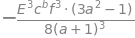

In [114]:
C_13_sol

$ C_{2,2}^{s,III}$ =

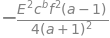

In [115]:
C_22_sol

$ C_{2,4}^{s,III}$ =

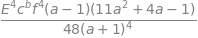

In [116]:
C_24_sol

$ C_{3}^{s,III}$ =

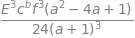

In [117]:
C_3_sol

$ C_{4}^{s,III}$ =

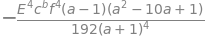

In [77]:
C_4_sol

## <ins>5. Determining the Models for Current</ins>

#### Finally, the surface concetration coefficients $C_{j}^{s,III}$ were used to determine the harmonic currents. To do so, the results were substituted into the equation for current (Equation 14), along with the relationships for $D^{III}$, $f$, and $a$ (per Frank et al.):
$$
\widetilde{I}_{j} = FAC_{j}^{s,III}\sqrt{\frac{j \omega D^{III}}{2}}(1+i) \tag{17}
$$
$$
D^{III} = D^0*(1+\delta) \tag{18}
$$
$$
f = \frac{F}{RT} \tag{19}
$$
$$
a = \sqrt{\frac{D^{III}}{D^{II}}} \approx 1+\delta \tag{20}
$$

#### Defining Variable Substitutions and Current Equation

I_generalForm =


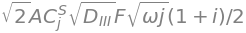

In [ ]:
#Defining New Variables
F,A,R,T,D_III,j,C_T, D_0, δ = sp.symbols('F A R T D_III j C_j^S D_0 δ',real=True) #C_T is the temporary surface concentration ratio w/ respect to C_0

#Defining Expressions to Substitute In
D_III_expr = D_0 * (1+δ)
f_expr = F/(R*T)
a_expr = 1 + δ
I_expr = F * A * (D_III*one_half)**(one_half) * ((1 + sp.I) * (j * w)**(one_half)) * C_T
I_expr = sp.collect(I_expr, j * w)
print("I_generalForm =")
I_expr

where $C_j^S$ represents the temporary placeholder (C_T) for a substituted concentration coefficient.

$ \text{First Harmonic Current } \widetilde{I}_{1} $

I_1 =


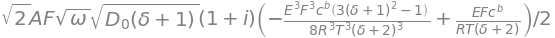

In [120]:
#Substitutions for f
C_11_sol_sub = C_11_sol.subs(f,f_expr)
C_13_sol_sub = C_13_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_1 = I_expr.subs({C_T: C_11_sol_sub+C_13_sol_sub, j: 1,D_III: D_III_expr,a:a_expr})

print("I_1 =")
I_1

$ \text{Second Harmonic Current } \widetilde{I}_{2} $

I_2 =


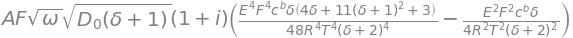

In [121]:
#Substitutions for f
C_22_sol_sub = C_22_sol.subs(f,f_expr)
C_24_sol_sub = C_24_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_2 = I_expr.subs({C_T: C_22_sol_sub+C_24_sol_sub, j: 2,D_III: D_III_expr, a:a_expr})

print("I_2 =")
I_2

$ \text{Third Harmonic Current } \widetilde{I}_{3} $

I_3 =


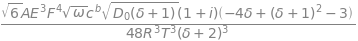

In [122]:
#Substitutions for f
C_3_sol_sub = C_3_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_3 = I_expr.subs({C_T: C_3_sol_sub, j: 3,D_III: D_III_expr, a:a_expr})

print("I_3 =")
I_3

#### **<span style="color:tomato;">★ Finally</span>**: These models ($\tilde{I}_j$) were then simplified outside of the notebook using a MacLaurin Series Expansion of the denominator of each term for the ${(δ+x)}^n$, where the term ${(1 + αδ)}^n$ can be approximated as $(1 + nαδ)$ when $δ << 1$ and $α$ is a constant (which is true for this case). See this below for the first and second harmonic currents:

### First Harmonic (j = 1):
$$
\tilde{I}_1 = AFc^b\sqrt{\frac{\omega D^0}{2}}(1+i)\left[
\underbrace{
\frac{-\Delta E^3 F^3 \left(3(\delta+1)^2 - 1\right)}{8 R^3 T^3 (\delta + 2)^3}
}_{\normalsize \text{ Group ①}}
+
\underbrace{
\frac{\Delta E F}{R T (\delta + 2)}
}_{\normalsize \text{ Group ②}}
\right]
$$

$$
\begin{gathered}
{\normalsize \text{ ① }} \frac{-\Delta E^3 F^3 \left(3(\delta+1)^2 - 1\right)}{8 R^3 T^3 (\delta + 2)^3} \\
\big\Downarrow \\
(\delta + 2)^{-3} = \frac{1}{2^3(0.5\delta+1)^3} \approx \frac{1}{8}(1-3(0.5\delta))
\end{gathered}
$$

$$
\begin{gathered}
(\delta + 1)^{2} =  1 + 2\delta \\
\big\Downarrow \\
= \frac{-\Delta E^3 F^3 \left(3 \overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1+2\delta)}} - 1\right) (1- \overset{\scriptstyle \color{red}{0\ since \ \delta<<0}}{\cancel{3(0.5\delta)}})}{64 R^3 T^3}
\end{gathered}
$$

$$
\boxed{{\normalsize \text{ ①}}=\frac{-\Delta E^3 F^3}{32 R^3 T^3}}
$$

$$
\\[2em]
\begin{gathered}
\normalsize \text{ ② } \frac{\Delta E F}{R T (\delta + 2)} \\
\big\Downarrow \\
(\delta + 2)^{-1} = \frac{1}{2(0.5\delta+1)} \approx \frac{1}{2}(1-0.5\delta) \\
\big\Downarrow \\
=\frac{\Delta E F \overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1-0.5\delta)}}}{2RT}
\end{gathered}
$$

$$
\boxed{\normalsize \text{ ②}= \frac{\Delta E F}{2RT}}
$$

$$
\\[2em]
 \therefore \ \tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0*\omega}{2}}*(1+i)*\left[1 - \frac{∆E^2F^2}{16R^2T^2} \right] * \frac{F∆E}{RT}
$$


### Second Harmonic (j = 2):
$$
\tilde{I}_2 = AFc^b\sqrt{\omega D^0}(1+i)\left[
\underbrace{
\frac{\Delta E^4F^4\delta(4\delta+11(\delta+1)^2+3)}{48R^4T^4(\delta+2)^4}
}_{\normalsize \text{Group ③}}
-
\underbrace{
\frac{\Delta E^2F^2\delta}{4R^2T^2(\delta+2)^2}
}_{\normalsize \text{Group ④}}
\right]
$$

$$
\begin{gathered}
\normalsize \text{③ } \frac{\Delta E^4F^4\delta(4\delta+11(\delta+1)^2+3)}{48R^4T^4(\delta+2)^4} \\
\big\Downarrow \\
(\delta + 2)^{-4} = \frac{1}{2^4(0.5\delta+1)^4} \approx \frac{1}{16}(1-4(0.5\delta))
\end{gathered}
$$

$$
\begin{gathered}
(\delta + 1)^{2} =  1 + 2\delta \\
\big\Downarrow \\
=\frac{\Delta E^4F^4\delta(4\delta+11(1+2\delta)+3)\overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1-4(0.5\delta))}}}{768R^4T^4} \\
=\frac{\Delta E^4F^4\delta(4\delta+11+22\delta+3)}{768R^4T^4} \\
=\frac{\Delta E^4F^4\delta(26\delta+14)}{768R^4T^4} \\
=\frac{\Delta E^4F^4\delta(13\delta+7)}{384R^4T^4} \\
=\frac{\Delta E^4F^4\delta*7\overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(\frac{13}{7}\delta+1)}}}{384R^4T^4}
\end{gathered}
$$

$$
\boxed{\normalsize \text{③ }=\frac{7\Delta E^4 F^4 \delta}{384 R^4 T^4}}
$$

$$
\\[2em]
\begin{gathered}
\normalsize \text{④ } \frac{\Delta E^2F^2\delta}{4R^2T^2(\delta+2)^2} \\
\big\Downarrow \\
(\delta + 2)^{-2} = \frac{1}{4(0.5\delta+1)^{2}} \approx \frac{1}{4}(1-2(0.5\delta)) \\
\big\Downarrow \\
=\frac{\Delta E^2F^2\delta \overset{\scriptstyle \color{red}{1\ since \ \delta<<0}}{\cancel{(1-2(0.5\delta))}}}{16R^2T^2}
\end{gathered}
$$

$$
\boxed{\normalsize \text{④ }= \frac{\Delta E^2F^2\delta}{16R^2T^2}}
$$

$$
\\[2em]
 \therefore \ \tilde{I}_2 = - \delta * \frac{FAc^b}{16}\sqrt{D^0*\omega}*(1+i)*\left[1 - \frac{7*\Delta E^2F^2}{24R^2T^2} \right] * \frac{F^2\Delta E^2}{R^2T^2}
$$

## <ins>6. Summary Results (2nd, 4th, and 6th Order)</ins>

#### Continuing this analysis to the sixth-order (N=6), the concentration coefficient results were tabulated:

<center>

| **Harmonic Order $j$** | **Modulation Order $k$** | **Coefficient $C_{j,k}^{s,III}$**                            | **Model Order $N$** |
|:----------------------:|:------------------------:|:------------------------------------------------------------:|:-------------------:|
|          1             |           1              | $\frac{∆Ec^bf}{a+1}$                                         |          2,4,6          |
|          2             |           2              | $-\frac{∆E^2c^bf^2(a-1)}{4(a+1)}$                            |          2,4,6          |
|          1             |           3              | $-\frac{∆E^3c^bf^3*(3a^2-1)}{8(a+1)^3}$                      |          4,6          |
|          2             |           4              | $\frac{∆E^4c^bf^4(a-1)(11a^2+4a-1)}{48(a+1)^4}$              |          4,6          |
|          3             |           3              | $\frac{∆E^3c^bf^3(a^2-4a+1)}{24(a+1)^3}$                                                  |          4,6          |
|          4             |           4              | $-\frac{∆E^4c^bf^4(a-1)(a^2-10a+1)}{192(a+1)^4}$                                                  |          4,6          |
|          1             |           5              | $\frac{∆E^5f^5(55a^4+4a^3-36a^3-8a+1)}{192(a+1)^5}$                                                  |          6          |
|          2             |           6              | $-\frac{∆E^6f^6(a-1)(353a^4+196a^3-66a^2-28a+1)}{1536(a+1)^6}$                                                  |          6          |
|          3             |           5              | $-\frac{∆E^5f^5(31a^4-62a^3-2a^2+18a-1)}{384(a+1)^5}$                                                  |          6          |
|          4             |           6              | $\frac{∆E^6f^6(a-1)(79a^4-272a^3-66a^2+46a-1)}{3840(a+1)^6}$                                                  |          6          |
|          5             |           5              | $\frac{∆E^5f^5(a^4-26a^3+66a^2-26a+1)}{1920(a+1)^5}$                                                  |          6          |
|          6             |           6              | $-\frac{∆E^6f^6(a-1)(a^4-56a^3+246a^2-56a+1)}{23040(a+1)^6}$                                                  |          6          |

</center>

#### where $f = \frac{F}{RT}$. Using a MacLaurin Series Expansion of each term from the substituted result of Equation 17 (like before), the simplified 2nd, 4th, and 6th-order <u>current models</u> were found:

<div style="text-align:center;">

#### <u>2nd-Order (N = 2)</u>:

$$
\tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0 \cdot \omega}{2}}*(1+i)*\frac{F ∆E}{RT}
$$

$$
\tilde{I}_2 = - \delta \cdot \frac{FAc^b}{16} \sqrt{D^0 \cdot \omega}*(1+i)*\frac{F^2 ∆E^2}{R^2 T^2}
$$

$$
\tilde{I}_3 = - \frac{FAc^b}{192} \sqrt{D^0 \cdot 6\omega}*(1+i)*\frac{F^3 ∆E^3}{R^3 T^3}
$$

#### <u>4th-Order (N = 4)</u>:

$$
\tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0 \cdot \omega}{2}}* (1+i) * \left[1 - \frac{∆E^2 F^2}{16 R^2 T^2} \right] * \frac{F ∆E}{RT}
$$

$$
\tilde{I}_2 = - \delta \cdot \frac{FAc^b}{16} \sqrt{D^0 \cdot \omega} * (1+i) * \left[1 - \frac{7 ∆E^2 F^2}{24 R^2 T^2} \right] * \frac{F^2 ∆E^2}{R^2 T^2}
$$

#### <u>6th-Order (N = 6)</u>:

$$
\tilde{I}_1 = \frac{FAc^b}{2}\sqrt{\frac{D^0 \cdot \omega}{2}}*(1+i) * \left[1 - \frac{∆E^2 F^2}{16 R^2 T^2} + \frac{∆E^4 F^4}{192 R^4 T^4} \right] * \frac{F ∆E}{RT}
$$

$$
\tilde{I}_2 = - \delta \cdot \frac{FAc^b}{16} \sqrt{D^0 \cdot \omega} * (1+i) * \left[1 - \frac{7 ∆E^2 F^2}{24 R^2 T^2} + \frac{19∆E^4 F^4}{256 R^4 T^4}\right] * \frac{F^2 ∆E^2}{R^2 T^2}
$$

</div>


#### These final models were the ones reported in Frank et. al.